# NLP Module - Level 6

# Text Classification Project

## Sources and notebook overview

This notebook was developed for the Level 6 NLP text classification project. The implementation was based initially on the CMP6231 text classification template, while the Word2Vec section was informed by the vector semantics lab material.

The workflow was then adapted to the AG News dataset and extended with exploratory data analysis, Bag of Words and TF-IDF experiments, classifier comparisons, a Word2Vec baseline, matched DistilBERT versus BERT subset experiments, and transformer ablation studies.

## Notebook structure

1. Data loading and exploration  
2. Traditional NLP: Bag of Words  
3. Traditional NLP: TF-IDF and Word2Vec  
4. Transformer fine-tuning  
5. Zero-shot classification  



## Setup
This section checks the runtime and installs the required libraries.

In [1]:
# Detect if we have a GPU available (Essential for Part 3)
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [2]:
# install dependencies
!pip install -q datasets transformers torch scikit-learn evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00


In [3]:

import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Import necessary classes from the Hugging Face Transformers library
from transformers import (
    AutoTokenizer,              # Automatically loads the tokenizer for a pretrained model
    AutoModelForSequenceClassification,  # Loads a pretrained model configured for sequence classification tasks
    Trainer,                    # High-level API for training and evaluating models
    TrainingArguments           # Configuration class to specify training hyperparameters
)

# Set a random seed for reproducibility of results
SEED = 42

# Set the random seed for NumPy (affects data shuffling, random arrays, etc.)
np.random.seed(SEED)

# Set the random seed for PyTorch (ensures reproducible model initialization and training)
torch.manual_seed(SEED)

## Section 1: Data loading and exploration

### Section Summary

The AG news dataset was loaded and split into a main training set, a validation set, and the official test set. The working split used 108,000 training examples, 12,000 validation examples, and 7,600 test examples.

The exploratory checks showed that the dataset was balanced across the four classes and that the text was clean enough for controlled comparison across models. This made it suitable for evaluating both traditional NLP pipelines and transformer-based approaches under the same classification task.

### Implementation notes / sources

- AG news dataset used for four-class news classification
- CMP6231 Text Classification Template
- Lab 2 vector semantics
- Text Classification Lab Material




*  Taha, K. et al. (2024), A comprehensive survey of text classification techniques and their research applications: observational and experimental insights, Computer Science Review. Avaliable at: https://nchr.elsevierpure.com/en/publications/a-comprehensive-survey-of-text-classification-techniques-and-thei


*   Christophe Pere, *Text Classification Compare Models* notebook: https://github.com/Christophe-pere/Model-Selection/blob/master/Text_Classification_Compare_Models.ipynb
*   pandas DataFrame.groupby documentation: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html



In [ ]:
# section 0: data loading
# i load the ag news csvs from a local data folder so the notebook is portable.
# i drop train.csv and test.csv into a folder called 'data' next to the notebook before running this.
# the kaggle ag news csvs have three columns: label, title, description.

from pathlib import Path

# i look first for a local data folder, and fall back to a colab drive mount if i'm running it there
DATA_DIR = Path("data")
if not DATA_DIR.exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DATA_DIR = Path("/content/drive/MyDrive/ag_news")
    except ImportError:
        raise FileNotFoundError(
            "i couldn't find a local 'data/' folder. "
            "place train.csv and test.csv in a folder called 'data' next to the notebook."
        )

print("using data folder:", DATA_DIR)


In [ ]:
# section 1: data loading and exploration

import pandas as pd

# i look for either plain csvs or zipped csvs so it works in either layout
def find_csv(folder, names):
    for name in names:
        p = folder / name
        if p.exists():
            return p
    raise FileNotFoundError(f"none of {names} found in {folder}")

train_path = find_csv(DATA_DIR, ["train.csv", "train.csv.zip"])
test_path = find_csv(DATA_DIR, ["test.csv", "test.csv.zip"])

# i load the ag news training and test splits
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# i rename the three columns to match the rest of the notebook
train_df.columns = ["label", "title", "description"]
test_df.columns = ["label", "title", "description"]

# i combine the title and description into one text column
train_df["text"] = train_df["title"] + " " + train_df["description"]
test_df["text"] = test_df["title"] + " " + test_df["description"]

# i peek at the first few rows to confirm the load worked
print(train_df.head())
print(test_df.head())

# i pull out the texts and labels for the modelling stages below
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]


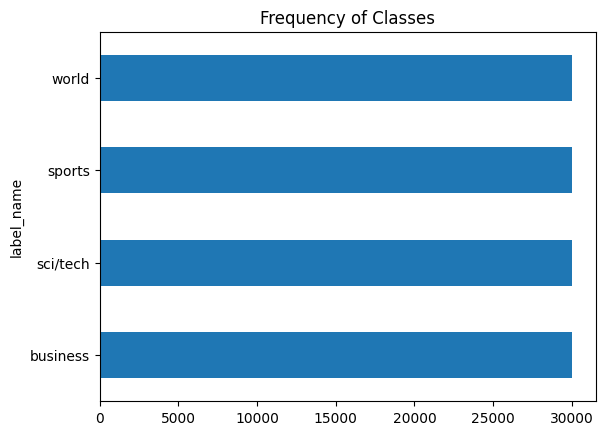

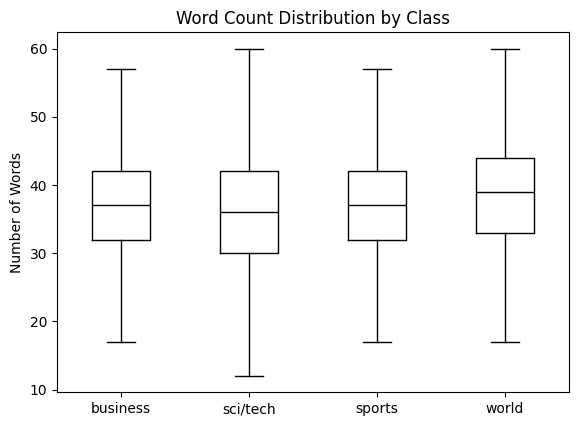

In [ ]:
import matplotlib.pyplot as plt

# creates copies so the analysis is easier to work with
train_explore_df = train_df.copy()
test_explore_df = test_df.copy()

# maps the class labels to class names
label_names = {
    1: "world",
    2: "sports",
    3: "business",
    4: "sci/tech"
}

train_explore_df["label_name"] = train_explore_df["label"].map(label_names)

# plots the class distribution
train_explore_df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

# calculates the number of words in each text
train_explore_df["words per article"] = train_explore_df["text"].str.split().apply(len)

# plots the text length distribution by class
train_explore_df.boxplot(
    "words per article",
    by="label_name",
    grid=False,
    showfliers=False,
    color="black"
)

plt.suptitle("")
plt.title("Word Count Distribution by Class")
plt.xlabel("")
plt.ylabel("Number of Words")
plt.show()

In [6]:
# 2: Check for missing values and empty text entries

# prints the number of missing values in each column
print(train_df[["label", "title", "description", "text"]].isnull().sum())

# checks for empty text values after removing spaces
empty_text_train = train_df["text"].str.strip() == ""

# prints the number of empty text rows
print("Empty Text Rows in Train Set:", empty_text_train.sum())

# removes rows with missing values in the main columns
train_df = train_df.dropna(subset=["label", "title", "description", "text"])

# removes rows with empty text
train_df = train_df[train_df["text"].str.strip() != ""]

# prints the shape after cleaning
print("Train Shape After Cleaning:", train_df.shape)

# extracts the cleaned texts and labels again
X_train = train_df["text"]
y_train = train_df["label"]

label          0
title          0
description    0
text           0
dtype: int64
Empty Text Rows in Train Set: 0
Train Shape After Cleaning: (120000, 4)


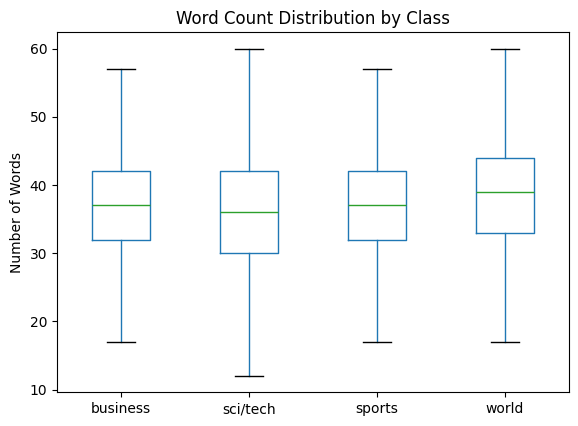

In [ ]:
# 3: Examine text length distribution

import matplotlib.pyplot as plt

# creates a copy of the training dataframe for exploration
train_explore_df = train_df.copy()

# maps the class labels to class names
label_names = {
    1: "world",
    2: "sports",
    3: "business",
    4: "sci/tech"
}

# adds the class names to the dataframe
train_explore_df["label_name"] = train_explore_df["label"].map(label_names)

# calculates the number of words in each article
train_explore_df["words per article"] = train_explore_df["text"].str.split().apply(len)

# plots the text length distribution by class
train_explore_df.boxplot(
    column="words per article",
    by="label_name",
    grid=False,
    showfliers=False
)

# removes the automatic pandas title
plt.suptitle("")

# adds the plot title
plt.title("Word Count Distribution by Class")

# removes the x-axis label
plt.xlabel("")

# adds the y-axis label
plt.ylabel("Number of Words")

# shows the plot
plt.show()

In [ ]:
# 4: Plot examples of text per class

# creates a copy of the training dataframe for inspection
task4_df = train_df.copy()

# maps the class labels to class names
label_names = {
    1: "world",
    2: "sports",
    3: "business",
    4: "sci/tech"
}

# adds the class names to the dataframe
task4_df["label_name"] = task4_df["label"].map(label_names)

# selects one example from each class
examples_per_class = task4_df.groupby("label_name").head(1)

# prints the class name and text for each example
print(examples_per_class[["label_name", "text"]])

    label_name                                               text
0     business  Wall St. Bears Claw Back Into the Black (Reute...
78    sci/tech  'Madden,' 'ESPN' Football Score in Different W...
448     sports  Phelps, Thorpe Advance in 200 Freestyle (AP) A...
492      world  Venezuelans Vote Early in Referendum on Chavez...


Source: CMP6231 Text Classification Template

## Section 2: Bag of Words

### Section Summary

The Bag of Words section established a strong traditional baseline for the project. The main bag of words plus Logistic Regression pipeline reached a validation accuracy of 0.9108.

The additional tests showed that adding bigrams improved performance, with unigram plus bigram features giving the best result among the n-gram settings at 0.9246 validation accuracy. Removing stopwords did not help, and increasing the vocabulary size improved performance only slightly. Among the classifier comparisons, multinomial naive bayes performed competitively, while linear svc was weaker than expected on this Bag of Words setup.

Overall, this section showed that a simple sparse representation can already perform strongly on ag news, but performance depends on design choices such as n-gram range and classifier selection.

### Implementation notes / sources

- Datacamp (2024), *Python Bag of Words Model: A complete guide*. Available at: https://www.datacamp.com/tutorial/python-bag-of-words-model
- CMP6231 Text Classification Template, adapted for AG news
- Lab 2 Vector Semantics
- Text Classification Lab Material
- NLPtown notebook, *Traditional Text Classification with scikit-learn*. Available at: https://github.com/nlptown/nlp-notebooks/blob/master/Traditional%20text%20classification%20with%20Scikit-learn.ipynb
- Scikit-learn Pipeline Documentation. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html



In [7]:
# imports train_test_split so i can create a validation split from the training data
from sklearn.model_selection import train_test_split

# splits the original training dataframe into a main training split and a validation split
train_main_df, val_df = train_test_split(
    train_df,
    test_size=0.10,
    stratify=train_df["label"],
    random_state=42
)

# creates the main training texts for the classical models
X_train_main = train_main_df["text"].astype(str)

# creates the main training labels for the classical models
y_train_main = train_main_df["label"].astype(int)

# creates the validation texts
X_val = val_df["text"].astype(str)

# creates the validation labels
y_val = val_df["label"].astype(int)

# keeps the official kaggle test split untouched for the final evaluation only
X_test_final = test_df["text"].astype(str)

# keeps the official kaggle test labels untouched for the final evaluation only
y_test_final = test_df["label"].astype(int)

# prints the split sizes so i can confirm everything worked correctly
print("train_main size:", len(train_main_df))
print("validation size:", len(val_df))
print("official test size:", len(test_df))

train_main size: 108000
validation size: 12000
official test size: 7600


Reference - Lab 2 Vector Semantics, Text Classification Template, and Text Classification Lab

In [8]:
# Section 2: Traditional NLP - Bag of Words

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# build the bag of words baseline pipeline
bow_pipeline = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# train the baseline only on the main training split
bow_pipeline.fit(X_train_main, y_train_main)

# predict labels for the validation split instead of the official test split
bow_val_preds = bow_pipeline.predict(X_val)

# print the validation results to can compare this baseline fairly with later classical settings
print("bag of words validation results")
print("accuracy:", accuracy_score(y_val, bow_val_preds))
print(classification_report(y_val, bow_val_preds))



bag of words validation results
accuracy: 0.91075
              precision    recall  f1-score   support

           1       0.92      0.90      0.91      3000
           2       0.96      0.97      0.97      3000
           3       0.87      0.88      0.88      3000
           4       0.89      0.89      0.89      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000



In [ ]:
# 1: Try different n-gram ranges

# imports the metric used to compare performance
from sklearn.metrics import accuracy_score

# build a bag of words pipeline with unigrams only
bow_unigram = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english", ngram_range=(1, 1))),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# train the unigram model on the main training split
bow_unigram.fit(X_train_main, y_train_main)

# predict the validation labels with the unigram model
unigram_val_preds = bow_unigram.predict(X_val)

# print the unigram validation accuracy
print("unigram validation accuracy:", accuracy_score(y_val, unigram_val_preds))

# build a bag of words pipeline with unigrams and bigrams
bow_bigram = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english", ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# train the unigram and bigram model on the main training split
bow_bigram.fit(X_train_main, y_train_main)

# predict the validation labels with the unigram and bigram model
bigram_val_preds = bow_bigram.predict(X_val)

# print the unigram and bigram validation accuracy
print("unigram + bigram validation accuracy:", accuracy_score(y_val, bigram_val_preds))

# build a bag of words pipeline with unigrams, bigrams and trigrams
bow_trigram = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english", ngram_range=(1, 3))),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# train the unigram, bigram and trigram model on the main training split
bow_trigram.fit(X_train_main, y_train_main)

# predict the validation labels with the unigram, bigram and trigram model
trigram_val_preds = bow_trigram.predict(X_val)

# print the unigram, bigram and trigram validation accuracy
print("unigram + bigram + trigram validation accuracy:", accuracy_score(y_val, trigram_val_preds))

unigram validation accuracy: 0.91075
unigram + bigram validation accuracy: 0.9245833333333333
unigram + bigram + trigram validation accuracy: 0.9238333333333333


In [ ]:
# 2: Experiment with removing stopwords

# builds a bag of words pipeline with stopwords removed
bow_with_stopwords_removed = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("classifier", LogisticRegression(max_iter=1000))
])

# trains the model with stopwords removed
bow_with_stopwords_removed = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# train the model with stopwords removed on the main training split
bow_with_stopwords_removed.fit(X_train_main, y_train_main)

# predict the validation labels with the stopwords removed model
stopwords_removed_val_preds = bow_with_stopwords_removed.predict(X_val)

# print the validation accuracy for the stopwords removed model
print("with stopwords removed validation accuracy:", accuracy_score(y_val, stopwords_removed_val_preds))

# build a bag of words pipeline without removing stopwords
bow_without_stopwords_removed = Pipeline([
    ("vectorizer", CountVectorizer(stop_words=None)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# train the model without stopwords removed on the main training split
bow_without_stopwords_removed.fit(X_train_main, y_train_main)

# predict the validation labels with the no stopword removal model
no_stopwords_removed_val_preds = bow_without_stopwords_removed.predict(X_val)

# print the validation accuracy for the no stopword removal model
print("without stopwords removed validation accuracy:", accuracy_score(y_val, no_stopwords_removed_val_preds))

with stopwords removed validation accuracy: 0.91075
without stopwords removed validation accuracy: 0.9113333333333333


In [ ]:
# 3: experiment with max_features

from sklearn.metrics import accuracy_score

# bag of words with max_features = 5000
bow_5000 = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english", max_features=5000)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

bow_5000.fit(X_train_main, y_train_main)
pred_5000 = bow_5000.predict(X_val)
print("max_features=5000 validation accuracy:", accuracy_score(y_val, pred_5000))

# bag of words with max_features = 10000
bow_10000 = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english", max_features=10000)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

bow_10000.fit(X_train_main, y_train_main)
pred_10000 = bow_10000.predict(X_val)
print("max_features=10000 validation accuracy:", accuracy_score(y_val, pred_10000))

# bag of words with max_features = 20000
bow_20000 = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english", max_features=20000)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

bow_20000.fit(X_train_main, y_train_main)
pred_20000 = bow_20000.predict(X_val)
print("max_features=20000 validation accuracy:", accuracy_score(y_val, pred_20000))

max_features=5000 validation accuracy: 0.9011666666666667
max_features=10000 validation accuracy: 0.9028333333333334
max_features=20000 validation accuracy: 0.9073333333333333


In [ ]:
# 4: Try different classifiers

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# builds a bag of words pipeline with multinomial naive bayes
bow_nb = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("classifier", MultinomialNB())
])

# trains the multinomial naive bayes model on the main training split
bow_nb.fit(X_train_main, y_train_main)

# predicts the validation labels with multinomial naive bayes
nb_preds = bow_nb.predict(X_val)

# prints the multinomial naive bayes validation accuracy
print("multinomial naive bayes validation accuracy:", accuracy_score(y_val, nb_preds))

# builds a bag of words pipeline with logistic regression
bow_lr = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# trains the logistic regression model on the main training split
bow_lr.fit(X_train_main, y_train_main)

# predicts the validation labels with logistic regression
lr_preds = bow_lr.predict(X_val)

# prints the logistic regression validation accuracy
print("logistic regression validation accuracy:", accuracy_score(y_val, lr_preds))

# builds a bag of words pipeline with linear svc
bow_svm = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("classifier", LinearSVC(random_state=42))
])

# trains the linear svc model on the main training split
bow_svm.fit(X_train_main, y_train_main)

# predicts the validation labels with linear svc
svm_preds = bow_svm.predict(X_val)

# prints the linear svc validation accuracy
print("linear svc validation accuracy:", accuracy_score(y_val, svm_preds))

multinomial naive bayes validation accuracy: 0.9126666666666666
logistic regression validation accuracy: 0.91075
linear svc validation accuracy: 0.8961666666666667


In [ ]:
# 5: Compare train and test accuracy

# calculates the train accuracy for multinomial naive bayes
nb_train_accuracy = bow_nb.score(X_train_main, y_train_main)

# calculates the validation accuracy for multinomial naive bayes
nb_val_accuracy = bow_nb.score(X_val, y_val)

# prints the train and validation accuracy for multinomial naive bayes
print("MultinomialNB Train Accuracy:", nb_train_accuracy)
print("MultinomialNB Validation Accuracy:", nb_val_accuracy)

# calculates the train accuracy for logistic regression
lr_train_accuracy = bow_lr.score(X_train_main, y_train_main)

# calculates the validation accuracy for logistic regression
lr_val_accuracy = bow_lr.score(X_val, y_val)

# prints the train and validation accuracy for logistic regression
print("Logistic Regression Train Accuracy:", lr_train_accuracy)
print("Logistic Regression Validation Accuracy:", lr_val_accuracy)

# calculates the train accuracy for linear svc
svm_train_accuracy = bow_svm.score(X_train_main, y_train_main)

# calculates the validation accuracy for linear svc
svm_val_accuracy = bow_svm.score(X_val, y_val)

# prints the train and validation accuracy for linear svc
print("Linear SVC Train Accuracy:", svm_train_accuracy)
print("Linear SVC Validation Accuracy:", svm_val_accuracy)

MultinomialNB Train Accuracy: 0.9203148148148148
MultinomialNB Validation Accuracy: 0.9126666666666666
Logistic Regression Train Accuracy: 0.9809629629629629
Logistic Regression Validation Accuracy: 0.91075
Linear SVC Train Accuracy: 0.9922592592592593
Linear SVC Validation Accuracy: 0.8961666666666667


## Section 3: TF-IDF and Word2Vec

This section compares TF-IDF against the Bag of Words baseline, evaluates multiple classifiers on TF-IDF features, and adds a Word2Vec-based dense embedding baseline for comparison.

### Section summary

The TF-IDF experiments improved on the Bag of Words baseline. TF-IDF with Logistic Regression reached a validation accuracy of 0.9224, which was better than the main Bag of Words result.

Classifier comparison on TF-IDF features showed that Linear SVC was the strongest traditional model in this section, reaching 0.9307 validation accuracy and 0.9268 accuracy on the official test set. In contrast, the averaged Word2Vec baseline reached 0.8664 validation accuracy, which was clearly weaker than the sparse-feature approaches.

Overall, this section showed that TF-IDF captured the most useful traditional representation for this task, while averaged static word embeddings lost too much task-specific detail compared with TF-IDF.

### Implementation notes / sources

- YouTube (2024), *Text analytics concepts: TF-IDF, Bag-of-Words explained with examples*. Available at: https://www.youtube.com/watch?v=LTgPMz3mT44
- CMP6231 text classification template, adapted for AG News
- Lab 2 Vector Semantics
- Al-Tarawneh, M.A.B. et al. (2024), *Enhancing fake news detection with word embedding*. Available at: https://www.mdpi.com/2073-431x/13/9/239
- Li, C. et al. (2025), *Short text classification based on enhanced word embedding and dual-channel hybrid neural network*. Available at: https://www.mdpi.com/2076-3417/15/9/5102
- Airline Tweets Sentiment repository. Available at: https://github.com/sychi77/Airline_Tweets_Sentiment

In [ ]:
# Section 3: Traditional NLP - TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

# builds the tf-idf pipeline
tfidf_pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english", ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# trains the tf-idf model on the main training split
tfidf_pipeline.fit(X_train_main, y_train_main)

# predicts the labels for the validation split
tfidf_val_preds = tfidf_pipeline.predict(X_val)

# prints the evaluation results
print("TF-IDF Validation Results")
print("Accuracy:", accuracy_score(y_val, tfidf_val_preds))
print(classification_report(y_val, tfidf_val_preds))


TF-IDF Validation Results
Accuracy: 0.9224166666666667
              precision    recall  f1-score   support

           1       0.93      0.91      0.92      3000
           2       0.95      0.98      0.97      3000
           3       0.90      0.89      0.90      3000
           4       0.91      0.90      0.91      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



In [ ]:
# 1: Compare TF-IDF and Bag of Words

# 1: Compare TF-IDF and Bag of Words

# calculates the bag of words validation accuracy
bow_accuracy = accuracy_score(y_val, bow_val_preds)

# calculates the tf-idf validation accuracy
tfidf_accuracy = accuracy_score(y_val, tfidf_val_preds)

# prints both accuracies
print("Bag of Words Validation Accuracy:", bow_accuracy)
print("TF-IDF Validation Accuracy:", tfidf_accuracy)

# checks which model performs better
if tfidf_accuracy > bow_accuracy:
    print("Better Model: TF-IDF")
elif bow_accuracy > tfidf_accuracy:
    print("Better Model: Bag of Words")
else:
    print("Better Model: Both Models Performed the Same")

Bag of Words Validation Accuracy: 0.91075
TF-IDF Validation Accuracy: 0.9224166666666667
Better Model: TF-IDF


In [10]:
# installs gensim
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 83.1 MB/s eta 0:00:00


### Word2Vec baseline
This experiment uses averaged Word2Vec embeddings as a simple dense semantic baseline. It is included to compare sparse lexical features with static dense embeddings, while recognising that mean-pooled word vectors lose word order and much document-level structure.

In [11]:
# 2: Experiment with Word2Vec

from gensim.models import Word2Vec
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# tokenises the main training text for word2vec
X_train_tokens = [text.split() for text in X_train_main]

# tokenises the validation text for word2vec
X_val_tokens = [text.split() for text in X_val]

# trains the word2vec model
word2vec_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

# creates a function to average word vectors for each text
def document_vector(tokens, model):
    valid_words = [word for word in tokens if word in model.wv]
    if len(valid_words) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[valid_words], axis=0)

# converts the training texts into document vectors
X_train_w2v = np.array([document_vector(tokens, word2vec_model) for tokens in X_train_tokens])

# converts the validation texts into document vectors
X_val_w2v = np.array([document_vector(tokens, word2vec_model) for tokens in X_val_tokens])

# trains logistic regression on the word2vec features
w2v_classifier = LogisticRegression(max_iter=1000, random_state=42)
w2v_classifier.fit(X_train_w2v, y_train_main)

# predicts the validation labels using the word2vec features
w2v_val_preds = w2v_classifier.predict(X_val_w2v)

# prints the evaluation results
print("Word2Vec Validation Results")
print("Accuracy:", accuracy_score(y_val, w2v_val_preds))
print(classification_report(y_val, w2v_val_preds))

Word2Vec Validation Results
Accuracy: 0.8658333333333333
              precision    recall  f1-score   support

           1       0.88      0.86      0.87      3000
           2       0.92      0.95      0.93      3000
           3       0.84      0.82      0.83      3000
           4       0.83      0.83      0.83      3000

    accuracy                           0.87     12000
   macro avg       0.87      0.87      0.87     12000
weighted avg       0.87      0.87      0.87     12000



In [12]:
# evaluate word2vec + logistic regression on the official ag news test set

# tokenises the official test text using the same scheme as training
X_test_tokens = [text.split() for text in X_test_final]

# converts the test texts into document vectors using the trained word2vec model
X_test_w2v = np.array([document_vector(tokens, word2vec_model) for tokens in X_test_tokens])

# predicts the official test labels using the already-trained classifier
w2v_test_preds = w2v_classifier.predict(X_test_w2v)

# prints the final word2vec test results
print("Word2Vec + Logistic Regression: Official Test Results")
print("Official Test Accuracy:", accuracy_score(y_test_final, w2v_test_preds))
print(classification_report(y_test_final, w2v_test_preds))

Word2Vec + Logistic Regression: Official Test Results
Official Test Accuracy: 0.8576315789473684
              precision    recall  f1-score   support

           1       0.87      0.87      0.87      1900
           2       0.91      0.95      0.93      1900
           3       0.83      0.80      0.81      1900
           4       0.82      0.81      0.82      1900

    accuracy                           0.86      7600
   macro avg       0.86      0.86      0.86      7600
weighted avg       0.86      0.86      0.86      7600



In [ ]:
# 3: Try different classifiers on tf-idf features

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# builds the tf-idf pipeline with multinomial naive bayes
tfidf_nb = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english", ngram_range=(1, 2))),
    ("classifier", MultinomialNB())
])

# trains the multinomial naive bayes model
tfidf_nb.fit(X_train_main, y_train_main)

# predicts the validation labels with multinomial naive bayes
tfidf_nb_val_preds = tfidf_nb.predict(X_val)

# prints the multinomial naive bayes validation accuracy
print("TF-IDF + MultinomialNB Validation Accuracy:", accuracy_score(y_val, tfidf_nb_val_preds))

# builds the tf-idf pipeline with logistic regression
tfidf_lr = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english", ngram_range=(1, 2))),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# trains the logistic regression model
tfidf_lr.fit(X_train_main, y_train_main)

# predicts the validation labels with logistic regression
tfidf_lr_val_preds = tfidf_lr.predict(X_val)

# prints the logistic regression validation accuracy
print("TF-IDF + Logistic Regression Validation Accuracy:", accuracy_score(y_val, tfidf_lr_val_preds))

# builds the tf-idf pipeline with linear svc
tfidf_svc = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english", ngram_range=(1, 2))),
    ("classifier", LinearSVC(random_state=42))
])

# trains the linear svc model
tfidf_svc.fit(X_train_main, y_train_main)

# predicts the validation labels with linear svc
tfidf_svc_val_preds = tfidf_svc.predict(X_val)

# prints the linear svc validation accuracy
print("TF-IDF + Linear SVC Validation Accuracy:", accuracy_score(y_val, tfidf_svc_val_preds))

TF-IDF + MultinomialNB Validation Accuracy: 0.91775
TF-IDF + Logistic Regression Validation Accuracy: 0.9224166666666667
TF-IDF + Linear SVC Validation Accuracy: 0.9306666666666666


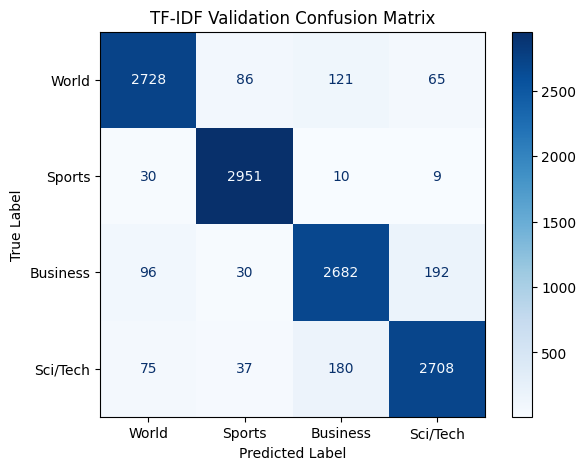

In [ ]:
# 4: Plot the confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# creates the confusion matrix from the true and predicted validation labels
cm = confusion_matrix(y_val, tfidf_val_preds)

# defines the class names for the display
class_labels = ["World", "Sports", "Business", "Sci/Tech"]

# creates the confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# plots the confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax)

# adds the plot title
plt.title("TF-IDF Validation Confusion Matrix")

# adds the x-axis label
plt.xlabel("Predicted Label")

# adds the y-axis label
plt.ylabel("True Label")

# shows the plot
plt.show()

TF-IDF + Linear SVC
Official Test Accuracy: 0.9268421052631579
              precision    recall  f1-score   support

           1       0.94      0.92      0.93      1900
           2       0.96      0.99      0.97      1900
           3       0.90      0.89      0.90      1900
           4       0.90      0.91      0.91      1900

    accuracy                           0.93      7600
   macro avg       0.93      0.93      0.93      7600
weighted avg       0.93      0.93      0.93      7600



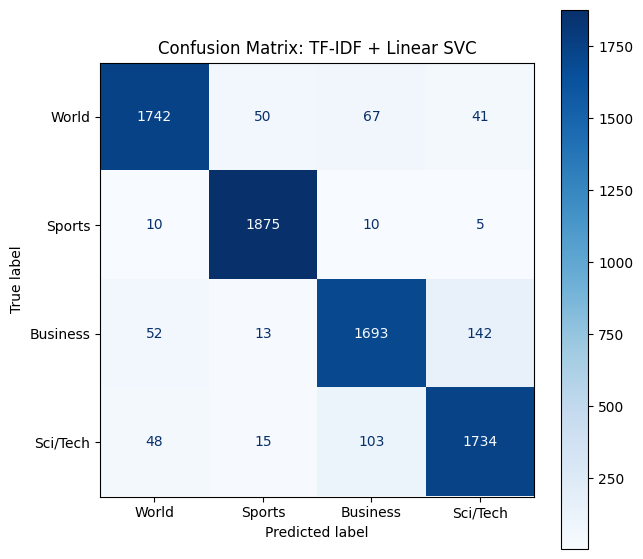

In [ ]:
# final classical evaluation on the official test split

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# chooses the best classical model from the validation experiments
best_classical_name = "TF-IDF + Linear SVC"
best_classical_model = Pipeline([
    ("vectorizer", TfidfVectorizer(stop_words="english", ngram_range=(1, 2))),
    ("clf", LinearSVC(random_state=42))
])

# creates the full training texts from the original training dataframe
X_train_full = train_df["text"].astype(str)

# creates the full training labels from the original training dataframe
y_train_full = train_df["label"].astype(int)

# creates the official test texts
X_test_final = test_df["text"].astype(str)

# creates the official test labels
y_test_final = test_df["label"].astype(int)

# fits the final chosen classical model on the full original training split
best_classical_model.fit(X_train_full, y_train_full)

# predicts the official test labels
best_classical_pred = best_classical_model.predict(X_test_final)

# prints the final test results
print(best_classical_name)
print("Official Test Accuracy:", accuracy_score(y_test_final, best_classical_pred))
print(classification_report(y_test_final, best_classical_pred))

# plots the final confusion matrix on the official test split
cm = confusion_matrix(y_test_final, best_classical_pred, labels=[1, 2, 3, 4])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["World", "Sports", "Business", "Sci/Tech"]
)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(cmap=plt.cm.Blues, values_format="d", ax=ax)
ax.set_title(f"Confusion Matrix: {best_classical_name}")
plt.show()

## Section 4: Transformer-Based Model (Finetuning)

### Section summary

The main transformer experiment showed that fine-tuned DistilBERT produced the strongest overall performance in the notebook. On the official test set, DistilBERT achieved about 0.95 accuracy with strong macro F1 performance, outperforming the traditional baselines.

The matched-subset comparison showed that both BERT and DistilBERT performed well on the smaller training setup, with BERT scoring slightly higher on the subset comparison, while DistilBERT remained competitive and more efficient.

The learning rate experiment showed that performance was sensitive to optimiser settings. Among the tested values, 5e-05 gave the strongest subset validation result at 0.8730 accuracy, slightly above 2e-05 and 1e-05. The sequence-length comparison showed only small differences, with 128 tokens performing best at 0.8730 validation accuracy, while 64 and 256 were slightly weaker. The freezing experiment showed a clearer effect, with full fine-tuning outperforming the frozen-base setup by a large margin, confirming that updating the transformer weights was important for this task.

Overall, this section showed that pretrained transformers gave the best classification performance, but that their results still depended on practical training choices such as learning rate, sequence length, and whether the encoder was frozen.

### Implementation notes / sources

- CMP6231 text classification template
- Hugging Face Transformers documentation:
  - Sequence classification: https://huggingface.co/docs/transformers/en/tasks/sequence_classification
  - Trainer: https://huggingface.co/docs/transformers/en/main_classes/trainer
  - Data collator: https://huggingface.co/docs/transformers/en/main_classes/data_collator
- Hugging Face Transformers GitHub example for text classification. Available at: https://github.com/huggingface/transformers/blob/main/examples/pytorch/text-classification/run_glue.py
- YouTube (2022), *Fine-tuning DistilBERT for multiclass text classification*. Available at: https://www.youtube.com/watch?v=ZvsH09XGuZ0
- Meléndez, R., Ptaszynski, M. and Masui, F. (2024), *Comparative investigation of traditional machine-learning models and transformer models for phishing email detection*. Available at: https://www.mdpi.com/2079-9292/13/24/4877
- *Comparative analysis of traditional machine learning and transformer-based deep learning models for text classification* (2025). Available at: https://dergipark.org.tr/tr/download/article-file/3867412
- *Scientific Reports paper on AI-generated content detection using DistilBERT* (2025). Available at: https://www.nature.com/articles/s41598-025-08208-7

In [ ]:
from transformers import DataCollatorWithPadding

In [ ]:
# Section 4: Transformer-based model (fine-tuning)

from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# creates copies for the transformer section
transformer_train_main_df = train_main_df.copy()
transformer_val_df = val_df.copy()
transformer_test_df = test_df.copy()

# changes the labels from 1-4 to 0-3 for the transformer model
transformer_train_main_df["label"] = transformer_train_main_df["label"] - 1
transformer_val_df["label"] = transformer_val_df["label"] - 1
transformer_test_df["label"] = transformer_test_df["label"] - 1

# creates a hugging face dataset from the dataframes
dataset = DatasetDict({
    "train": Dataset.from_pandas(transformer_train_main_df[["text", "label"]], preserve_index=False),
    "validation": Dataset.from_pandas(transformer_val_df[["text", "label"]], preserve_index=False),
    "test": Dataset.from_pandas(transformer_test_df[["text", "label"]], preserve_index=False)
})

model_checkpoint = "distilbert-base-uncased"
num_labels = len(set(transformer_train_main_df["label"]))

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels
)

# tokenisation function
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True)

# tokenise dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch")

# creates a data collator for dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# metric function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    report_to="none",
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

# validation results during model selection
val_results = trainer.evaluate(tokenized_dataset["validation"])
print("DistilBERT Validation Results")
print(val_results)

# final official test results
test_results = trainer.evaluate(tokenized_dataset["test"])
print("DistilBERT Official Test Results")
print(test_results)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.186678,0.178676,0.941167,0.941121
2,0.113611,0.184713,0.947917,0.947867


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


DistilBERT Validation Results
{'eval_loss': 0.18471263349056244, 'eval_accuracy': 0.9479166666666666, 'eval_macro_f1': 0.9478669382543599, 'eval_runtime': 34.1052, 'eval_samples_per_second': 351.853, 'eval_steps_per_second': 21.991, 'epoch': 2.0}
DistilBERT Official Test Results
{'eval_loss': 0.1888032704591751, 'eval_accuracy': 0.9465789473684211, 'eval_macro_f1': 0.9466188277684215, 'eval_runtime': 21.5398, 'eval_samples_per_second': 352.835, 'eval_steps_per_second': 22.052, 'epoch': 2.0}


Source: CMP6231 Text Classification Template

DistilBERT Classification Report
              precision    recall  f1-score   support

       World       0.96      0.95      0.96      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.92      0.91      0.92      1900
    Sci/Tech       0.91      0.94      0.92      1900

    accuracy                           0.95      7600
   macro avg       0.95      0.95      0.95      7600
weighted avg       0.95      0.95      0.95      7600



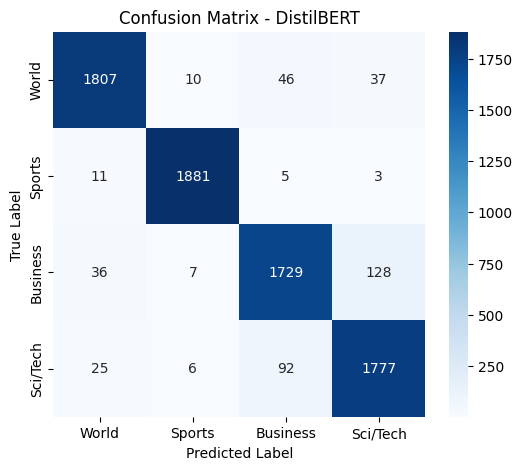

In [ ]:
# model evaluation

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# gets predictions from the transformer model on the official test split
predictions = trainer.predict(tokenized_dataset["test"])

# converts logits to predicted class labels
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# defines the class names
label_names = ["World", "Sports", "Business", "Sci/Tech"]

# prints the classification report
print("DistilBERT Classification Report")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_names
    )
)

# creates the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# plots the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DistilBERT")
plt.show()

# Model comparison on matched subset DistilBERT on subset BERT on same subset

In [ ]:
# 1: Compare distilbert and bert on the same subset adapted from hugging face trainer-based text classification examples

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# removes old output folders so they do not take up storage
!rm -rf distilbert_subset_results
!rm -rf bert_subset_results
!rm -rf distilbert_subset_logs
!rm -rf bert_subset_logs

# sets the two checkpoints i want to compare
model_names = {
    "DistilBERT": "distilbert-base-uncased",
    "BERT": "bert-base-uncased"
}

# stores the final results for task 1
task1_results = []

# creates one fixed subset so both models use exactly the same training and validation data
subset_train = dataset["train"].shuffle(seed=42).select(range(2000))
subset_val = dataset["validation"].shuffle(seed=42).select(range(1000))

# loops through each model so the setup is the same for both
for model_label, checkpoint in model_names.items():

    print(f"\nRunning {model_label} on the same subset")

    # loads the tokenizer for the current model
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)

    # tokenises the text using the current tokenizer
    def tokenize_function(examples):
        return tokenizer(examples["text"], truncation=True)

    # tokenises both the training and validation subset
    tokenized_train = subset_train.map(tokenize_function, batched=True)
    tokenized_val = subset_val.map(tokenize_function, batched=True)

    # removes the raw text column because the model does not need it
    tokenized_train = tokenized_train.remove_columns(["text"])
    tokenized_val = tokenized_val.remove_columns(["text"])

    # renames label to labels because hugging face models expect that column name
    tokenized_train = tokenized_train.rename_column("label", "labels")
    tokenized_val = tokenized_val.rename_column("label", "labels")

    # converts the datasets into pytorch format
    tokenized_train.set_format("torch")
    tokenized_val.set_format("torch")

    # loads the sequence classification model with the right number of classes
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=num_labels
    )

    # creates dynamic padding so each batch is padded only as much as needed
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # sets the training arguments
    training_args = TrainingArguments(
        output_dir=f"./{model_label.lower()}_subset_results",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,
        weight_decay=0.01,
        logging_dir=f"./{model_label.lower()}_subset_logs",
        report_to="none",
        seed=42
    )

    # creates the trainer using the validation subset for comparison
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=data_collator
    )

    # trains the model
    trainer.train()

    # gets predictions on the validation subset
    predictions = trainer.predict(tokenized_val)

    # turns the raw logits into final predicted class ids
    pred_labels = np.argmax(predictions.predictions, axis=1)

    # gets the true labels
    true_labels = predictions.label_ids

    # calculates accuracy
    accuracy = accuracy_score(true_labels, pred_labels)

    # calculates macro f1
    macro_f1 = f1_score(true_labels, pred_labels, average="macro")

    # stores the results so i can compare both models easily
    task1_results.append({
        "model": model_label,
        "train_size": len(subset_train),
        "validation_size": len(subset_val),
        "epochs": 1,
        "learning_rate": 2e-5,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })

    # prints the results for the current model
    print(f"{model_label} validation accuracy: {accuracy:.4f}")
    print(f"{model_label} validation macro f1: {macro_f1:.4f}")

# prints the final side by side comparison
print("\nTask 1 Final Comparison")
for row in task1_results:
    print(row)


Running DistilBERT on the same subset


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Epoch,Training Loss,Validation Loss
1,No log,0.366514


BERT validation accuracy: 0.8850
BERT validation macro f1: 0.8865

Task 1 Final Comparison
{'model': 'DistilBERT', 'train_size': 2000, 'validation_size': 1000, 'epochs': 1, 'learning_rate': 2e-05, 'accuracy': 0.869, 'macro_f1': 0.8704827233734871}
{'model': 'BERT', 'train_size': 2000, 'validation_size': 1000, 'epochs': 1, 'learning_rate': 2e-05, 'accuracy': 0.885, 'macro_f1': 0.8865216764506872}


Source: CMP6231 Text Classification Template, adapted for AG News


evaluating DistilBERT


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss
1,No log,0.379969


DistilBERT validation accuracy: 0.8670
DistilBERT validation macro f1: 0.8688

DistilBERT classification report
              precision    recall  f1-score   support

       World       0.90      0.86      0.88       272
      Sports       0.94      0.96      0.95       226
    Business       0.79      0.85      0.82       245
    Sci/Tech       0.84      0.81      0.82       257

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



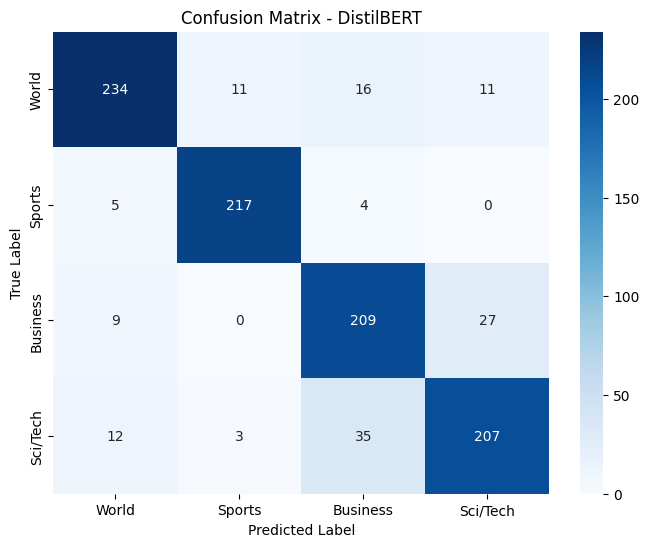


evaluating BERT


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Epoch,Training Loss,Validation Loss
1,No log,0.366514


BERT validation accuracy: 0.8850
BERT validation macro f1: 0.8865

BERT classification report
              precision    recall  f1-score   support

       World       0.94      0.85      0.89       272
      Sports       0.93      0.99      0.96       226
    Business       0.81      0.88      0.84       245
    Sci/Tech       0.86      0.84      0.85       257

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.88      1000



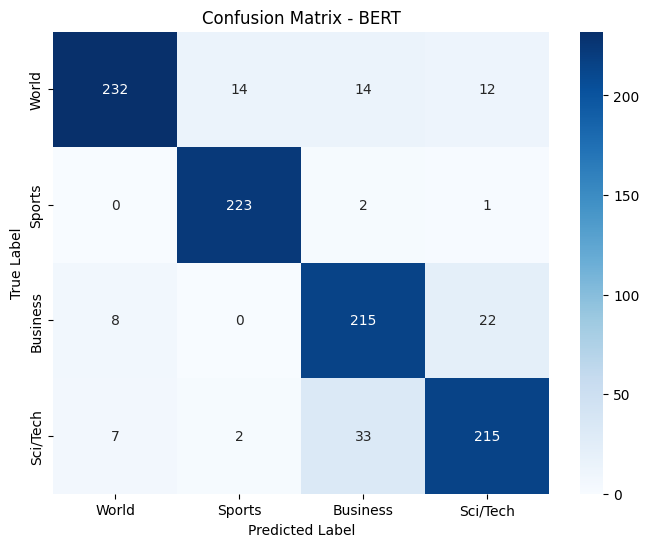


final detailed comparison
{'model': 'DistilBERT', 'accuracy': 0.867, 'macro_f1': 0.8688225726061243}
{'model': 'BERT', 'accuracy': 0.885, 'macro_f1': 0.8865216764506872}


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# class names for the report and confusion matrix
class_names = ["World", "Sports", "Business", "Sci/Tech"]

# stores the detailed results for both models
task1_detailed_results = []

# loops through both models using the same subset
for model_label, checkpoint in model_names.items():

    print(f"\n{'='*60}")
    print(f"evaluating {model_label}")
    print(f"{'='*60}")

    # loads the tokenizer for the current model
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)

    # tokenises the text
    def tokenize_function(examples):
        return tokenizer(examples["text"], truncation=True)

    # tokenises the same train and validation subset for both models
    tokenized_train = subset_train.map(tokenize_function, batched=True)
    tokenized_val = subset_val.map(tokenize_function, batched=True)

    # removes the original text column
    tokenized_train = tokenized_train.remove_columns(["text"])
    tokenized_val = tokenized_val.remove_columns(["text"])

    # renames the label column to labels
    tokenized_train = tokenized_train.rename_column("label", "labels")
    tokenized_val = tokenized_val.rename_column("label", "labels")

    # changes the datasets into pytorch format
    tokenized_train.set_format("torch")
    tokenized_val.set_format("torch")

    # loads the model with the correct number of output classes
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=num_labels
    )

    # creates dynamic padding for batches
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # sets the training arguments
    training_args = TrainingArguments(
        output_dir=f"./{model_label.lower()}_subset_results",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,
        weight_decay=0.01,
        logging_dir=f"./{model_label.lower()}_subset_logs",
        report_to="none",
        seed=42
    )

    # creates the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=data_collator
    )

    # trains the model
    trainer.train()

    # gets predictions on the validation subset
    predictions = trainer.predict(tokenized_val)

    # converts logits into predicted class labels
    pred_labels = np.argmax(predictions.predictions, axis=1)

    # gets the true labels
    true_labels = predictions.label_ids

    # calculates accuracy and macro f1
    accuracy = accuracy_score(true_labels, pred_labels)
    macro_f1 = f1_score(true_labels, pred_labels, average="macro")

    # stores the main metrics
    task1_detailed_results.append({
        "model": model_label,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })

    print(f"{model_label} validation accuracy: {accuracy:.4f}")
    print(f"{model_label} validation macro f1: {macro_f1:.4f}")

    print(f"\n{model_label} classification report")
    print(classification_report(
        true_labels,
        pred_labels,
        target_names=class_names
    ))

    # builds the confusion matrix
    cm = confusion_matrix(true_labels, pred_labels)

    # plots the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_label}")
    plt.show()

print("\nfinal detailed comparison")
for row in task1_detailed_results:
    print(row)

In [ ]:
# 2: Test learning rate sensitivity with distilbert adapted from hugging face trainer-based text classification examples

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# removes old output folders so they do not take up storage
!rm -rf distilbert_lr_1e5_results
!rm -rf distilbert_lr_2e5_results
!rm -rf distilbert_lr_5e5_results
!rm -rf distilbert_lr_1e5_logs
!rm -rf distilbert_lr_2e5_logs
!rm -rf distilbert_lr_5e5_logs

# sets the checkpoint i want to keep fixed for the sensitivity test
checkpoint = "distilbert-base-uncased"

# loads the tokenizer
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

# uses the same subset size for quicker repeat experiments
subset_train = dataset["train"].shuffle(seed=42).select(range(2000))
subset_val = dataset["validation"].shuffle(seed=42).select(range(1000))

# tokenises the text
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True)

# tokenises both subsets
tokenized_train = subset_train.map(tokenize_function, batched=True)
tokenized_val = subset_val.map(tokenize_function, batched=True)

# removes the raw text column
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val = tokenized_val.remove_columns(["text"])

# renames label to labels for hugging face
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")

# converts the datasets into pytorch format
tokenized_train.set_format("torch")
tokenized_val.set_format("torch")

# creates dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# stores the learning rates i want to test
learning_rates = [1e-5, 2e-5, 5e-5]

# stores the final results for task 2
task2_results = []

# loops through each learning rate
for lr in learning_rates:

    print(f"\nRunning DistilBERT with learning rate = {lr}")

    # loads a fresh distilbert model each time
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=num_labels
    )

    # creates a clean folder name for each learning rate
    lr_name = str(lr).replace("-", "").replace(".", "")

    # sets the training arguments
    training_args = TrainingArguments(
        output_dir=f"./distilbert_lr_{lr_name}_results",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=lr,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,
        weight_decay=0.01,
        logging_dir=f"./distilbert_lr_{lr_name}_logs",
        report_to="none",
        seed=42
    )

    # creates the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=data_collator
    )

    # trains the model
    trainer.train()

    # gets predictions on the validation subset
    predictions = trainer.predict(tokenized_val)

    # turns the raw logits into final predicted class ids
    pred_labels = np.argmax(predictions.predictions, axis=1)

    # gets the true labels
    true_labels = predictions.label_ids

    # calculates accuracy
    accuracy = accuracy_score(true_labels, pred_labels)

    # calculates macro f1
    macro_f1 = f1_score(true_labels, pred_labels, average="macro")

    # stores the results
    task2_results.append({
        "model": "DistilBERT",
        "train_size": len(subset_train),
        "validation_size": len(subset_val),
        "epochs": 1,
        "learning_rate": lr,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })

    # prints the results for the current run
    print(f"learning rate: {lr}")
    print(f"validation accuracy: {accuracy:.4f}")
    print(f"validation macro f1: {macro_f1:.4f}")

# prints the final comparison
print("\nTask 2 Final Comparison")
for row in task2_results:
    print(row)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


Running DistilBERT with learning rate = 1e-05


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


...

learning rate: 2e-05
validation accuracy: 0.8670
validation macro f1: 0.8688

Running DistilBERT with learning rate = 5e-05


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss
1,No log,0.398643


learning rate: 5e-05
validation accuracy: 0.8730
validation macro f1: 0.8744

Task 2 Final Comparison
{'model': 'DistilBERT', 'train_size': 2000, 'validation_size': 1000, 'epochs': 1, 'learning_rate': 1e-05, 'accuracy': 0.858, 'macro_f1': 0.859294932706625}
{'model': 'DistilBERT', 'train_size': 2000, 'validation_size': 1000, 'epochs': 1, 'learning_rate': 2e-05, 'accuracy': 0.867, 'macro_f1': 0.8688225726061243}
{'model': 'DistilBERT', 'train_size': 2000, 'validation_size': 1000, 'epochs': 1, 'learning_rate': 5e-05, 'accuracy': 0.873, 'macro_f1': 0.87442981496803}


## Max Sequence Length Comparison

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# stores the results for each max length
task3_results = []

# uses distilbert for this comparison
checkpoint = "distilbert-base-uncased"

# loads the tokenizer
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

# tests different max sequence lengths
max_lengths = [64, 128, 256]

for max_len in max_lengths:

    print(f"\nrunning distilbert with max length = {max_len}")

    # tokenises the subset using the current max length
    def tokenize_function(examples):
        return tokenizer(examples["text"], truncation=True, max_length=max_len)

    tokenized_train = subset_train.map(tokenize_function, batched=True)
    tokenized_val = subset_val.map(tokenize_function, batched=True)

    # removes the raw text column
    tokenized_train = tokenized_train.remove_columns(["text"])
    tokenized_val = tokenized_val.remove_columns(["text"])

    # renames label to labels
    tokenized_train = tokenized_train.rename_column("label", "labels")
    tokenized_val = tokenized_val.rename_column("label", "labels")

    # changes the datasets into pytorch format
    tokenized_train.set_format("torch")
    tokenized_val.set_format("torch")

    # creates dynamic padding
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # loads a fresh model
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=num_labels
    )

    # creates training settings
    training_args = TrainingArguments(
        output_dir=f"./distilbert_maxlen_{max_len}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,
        weight_decay=0.01,
        report_to="none",
        seed=42
    )

    # creates the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=data_collator
    )

    # trains the model
    trainer.train()

    # gets predictions
    predictions = trainer.predict(tokenized_val)

    # gets predicted labels
    pred_labels = np.argmax(predictions.predictions, axis=1)

    # gets true labels
    true_labels = predictions.label_ids

    # calculates accuracy and macro f1
    accuracy = accuracy_score(true_labels, pred_labels)
    macro_f1 = f1_score(true_labels, pred_labels, average="macro")

    # stores the results
    task3_results.append({
        "max_length": max_len,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })

    print(f"validation accuracy: {accuracy:.4f}")
    print(f"validation macro f1: {macro_f1:.4f}")

print("\ntask 3 results")
for row in task3_results:
    print(row)


running distilbert with max length = 64


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,No log,0.378649


validation accuracy: 0.8690
validation macro f1: 0.8707

task 3 results
{'max_length': 64, 'accuracy': 0.871, 'macro_f1': 0.8729055513013803}
{'max_length': 128, 'accuracy': 0.873, 'macro_f1': 0.8746678751430903}
{'max_length': 256, 'accuracy': 0.869, 'macro_f1': 0.8707346112683102}


Source: CMP6231 Text Classification Template, adapted for AG News

## Freezing layers

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# stores the results for frozen and unfrozen runs
task4_results = []

# uses distilbert for this experiment
checkpoint = "distilbert-base-uncased"

# loads the tokenizer
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

# tokenises the subset
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True)

tokenized_train = subset_train.map(tokenize_function, batched=True)
tokenized_val = subset_val.map(tokenize_function, batched=True)

# removes the raw text column
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val = tokenized_val.remove_columns(["text"])

# renames label to labels
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")

# changes the datasets into pytorch format
tokenized_train.set_format("torch")
tokenized_val.set_format("torch")

# creates dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# tests two settings
freeze_settings = [False, True]

for freeze_base in freeze_settings:

    if freeze_base:
        print("\nrunning distilbert with frozen base model")
    else:
        print("\nrunning distilbert with full fine-tuning")

    # loads a fresh model
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=num_labels
    )

    # freezes the base transformer layers and leaves the classifier trainable
    if freeze_base:
        for param in model.base_model.parameters():
            param.requires_grad = False

    # creates training settings
    training_args = TrainingArguments(
        output_dir=f"./distilbert_freeze_{freeze_base}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=1,
        weight_decay=0.01,
        report_to="none",
        seed=42
    )

    # creates the trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        data_collator=data_collator
    )

    # trains the model
    trainer.train()

    # gets predictions
    predictions = trainer.predict(tokenized_val)

    # gets predicted labels
    pred_labels = np.argmax(predictions.predictions, axis=1)

    # gets true labels
    true_labels = predictions.label_ids

    # calculates accuracy and macro f1
    accuracy = accuracy_score(true_labels, pred_labels)
    macro_f1 = f1_score(true_labels, pred_labels, average="macro")

    # stores the results
    task4_results.append({
        "freeze_base_model": freeze_base,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })

    print(f"validation accuracy: {accuracy:.4f}")
    print(f"validation macro f1: {macro_f1:.4f}")

print("\ntask 4 results")
for row in task4_results:
    print(row)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


running distilbert with full fine-tuning


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

validation accuracy: 0.8670
validation macro f1: 0.8688

running distilbert with frozen base model


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,No log,1.205542


validation accuracy: 0.8040
validation macro f1: 0.8071

task 4 results
{'freeze_base_model': False, 'accuracy': 0.867, 'macro_f1': 0.8688225726061243}
{'freeze_base_model': True, 'accuracy': 0.804, 'macro_f1': 0.8070739390549241}


Source: CMP6231 Text Classification Template, adapted for AG News

## Section 5: Zero Shot LLM

### Section summary

The zero-shot FLAN-T5 experiment was included as a supplementary comparison rather than a main result. It showed that zero-shot prompting could sometimes produce correct labels, but performance was less reliable than the supervised methods because predictions were occasionally mapped to unexpected label names such as "science" or "unknown".

This made the zero-shot setup useful for quick experimentation and for illustrating how an instruction-tuned model can attempt classification without task-specific training, but it was clearly weaker and less stable than both the TF-IDF baseline and the fine-tuned DistilBERT model.

Overall, this section supported the conclusion that zero-shot classification can be useful for rapid testing, but supervised fine-tuning is the better choice when labelled data is available and strong task-specific performance is required.

### Implementation notes / sources

- CMP6231 text classification template
- YouTube (2024), *Step-by-step implementation of text classification with FLAN-T5*. Available at: https://www.youtube.com/watch?v=umO0U_Bot-E




In [ ]:
# section 5: optional - zero-shot llm classification with flan-t5
# adapted from the provided coursework template

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sklearn.metrics import accuracy_score, classification_report
import torch

# loads the flan-t5 model from the template
model_name = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# moves the model to gpu if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# defines the class labels
labels = ["World", "Sports", "Business", "Sci/Tech"]

# this function generates a zero-shot prediction using a prompt
def zero_shot_classify(text, labels, prompt_template="Classify the following news into one of these categories: {}. News: '{}'"):
    prompt = prompt_template.format(", ".join(labels), text)

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    outputs = model.generate(**inputs, max_length=20)
    prediction = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return prediction

# this function maps flan output back to one of the expected labels
def map_prediction_to_label(prediction, labels):
    prediction_lower = prediction.lower().strip()

    for label in labels:
        if label.lower() in prediction_lower:
            return label

    return "Unknown"

# creates a small subset for quick zero-shot testing
zero_shot_subset = dataset["test"].select(range(50))

# stores the true and predicted labels
true_labels = []
predicted_labels = []

# prompt template 1
prompt1 = "Classify the following news into one of these categories: {}. News: '{}'"

print("=== zero-shot predictions on sample subset ===")

for example in zero_shot_subset:
    text = example["text"]
    true_label = labels[example["label"]]

    raw_prediction = zero_shot_classify(text, labels, prompt_template=prompt1)
    mapped_prediction = map_prediction_to_label(raw_prediction, labels)

    true_labels.append(true_label)
    predicted_labels.append(mapped_prediction)

    print(f"text: {text[:120]}...")
    print(f"true label: {true_label}")
    print(f"raw prediction: {raw_prediction}")
    print(f"mapped prediction: {mapped_prediction}")
    print()

# calculates zero-shot accuracy
zero_shot_accuracy = accuracy_score(true_labels, predicted_labels)

print("zero-shot accuracy on 50 samples:", zero_shot_accuracy)

# prints the classification report
print("\nzero-shot classification report")
print(classification_report(true_labels, predicted_labels, labels=labels, zero_division=0))

# task 1: compare different prompt templates on one example
sample_text = dataset["test"][0]["text"]

prompt2 = "Which category does this news belong to: {}. Text: '{}'"
prompt3 = "Categorize this news article into one of these labels: {}. Article: '{}'"

print("\nprompt comparison")
print("prompt 1:", zero_shot_classify(sample_text, labels, prompt_template=prompt1))
print("prompt 2:", zero_shot_classify(sample_text, labels, prompt_template=prompt2))
print("prompt 3:", zero_shot_classify(sample_text, labels, prompt_template=prompt3))

# task 3: compare label order
labels_shuffled = ["Sci/Tech", "Business", "Sports", "World"]

print("\nlabel order comparison")
print("original order:", zero_shot_classify(sample_text, labels, prompt_template=prompt1))
print("shuffled order:", zero_shot_classify(sample_text, labels_shuffled, prompt_template=prompt1))

# example comparison with a supervised model
print("\nsupervised vs zero-shot example")
print("tf-idf prediction:", labels[tfidf_pipeline.predict([sample_text])[0] - 1])
print("zero-shot flan-t5 prediction:", map_prediction_to_label(zero_shot_classify(sample_text, labels, prompt_template=prompt1), labels))

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


=== zero-shot predictions on sample subset ===
text: Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks...
true label: Business
raw prediction: Business
mapped prediction: Business

text: The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A ...
true label: Sci/Tech
raw prediction: Science
mapped prediction: Unknown

text: Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemistry researcher at the University of Loui...
true label: Sci/Tech
raw prediction: Science
mapped prediction: Unknown

text: Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur o...
true label: Sci/Tech
raw prediction: World
mapped prediction: World

text: Calif. Aims to Limit Farm-Related Smog (AP) AP - Southern California's smog-fighting agency went after emissions of the ...
true label: S

Source: CMP6231 Text Classification Template

# Robust classical benchmark

### Section summary

This section strengthened the traditional-model comparison by using grid search with five-fold cross-validation across multiple classical pipelines. The results showed that TF-IDF plus Linear SVC remained the strongest classical approach, with the best cross-validated macro F1 and the best held-out test performance among the benchmarked traditional models.

TF-IDF plus Logistic Regression also performed strongly, while Bag of Words plus Logistic Regression and TF-IDF plus Naive Bayes were weaker. This confirmed that the earlier TF-IDF findings were not one-off results, but remained strong under a more systematic tuning procedure.

Overall, this section improved the reliability of the classical baseline comparison and made the model selection process more rigorous.

### Implementation notes / sources

- NLPTown notebook, *Traditional text classification with scikit-learn*. Available at: https://github.com/nlptown/nlp-notebooks/blob/master/Traditional%20text%20classification%20with%20Scikit-learn.ipynb
- Scikit-learn documentation for pipelines, grid search, and evaluation metrics
- Additional benchmarking inspiration from practical text classification notebooks used during development


In [ ]:
# reference pattern:
# github notebook for traditional text classification pipelines:
# https://github.com/nlptown/nlp-notebooks/blob/master/Traditional%20text%20classification%20with%20Scikit-learn.ipynb
#
# github notebook for keeping train / validation / test usage disciplined:
# https://github.com/anthony-wang/BestPractices/blob/master/notebooks/2-data_splitting.ipynb
#
# recent paper supporting strong bow / tf-idf baselines:
# https://www.sciencedirect.com/science/article/pii/S2949719125000305

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

# uses the full original training split for model fitting and cross-validation
X_train = train_df["text"].astype(str)
y_train = train_df["label"].astype(int)

# keeps the official test split for the final held-out evaluation
X_test = test_df["text"].astype(str)
y_test = test_df["label"].astype(int)

# creates a stratified five-fold split so each fold keeps class balance
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# defines the model spaces to compare
model_spaces = [
    {
        "name": "bow_logreg",
        "pipeline": Pipeline([
            ("vectorizer", CountVectorizer()),
            ("clf", LogisticRegression(max_iter=1000, random_state=42))
        ]),
        "params": {
            "vectorizer__ngram_range": [(1, 1), (1, 2)],
            "vectorizer__stop_words": ["english", None],
            "vectorizer__max_features": [10000, 20000],
            "clf__C": [0.5, 1.0, 2.0]
        }
    },
    {
        "name": "tfidf_logreg",
        "pipeline": Pipeline([
            ("vectorizer", TfidfVectorizer()),
            ("clf", LogisticRegression(max_iter=1000, random_state=42))
        ]),
        "params": {
            "vectorizer__ngram_range": [(1, 1), (1, 2)],
            "vectorizer__stop_words": ["english", None],
            "vectorizer__max_features": [10000, 20000],
            "clf__C": [0.5, 1.0, 2.0]
        }
    },
    {
        "name": "tfidf_svc",
        "pipeline": Pipeline([
            ("vectorizer", TfidfVectorizer()),
            ("clf", LinearSVC(random_state=42))
        ]),
        "params": {
            "vectorizer__ngram_range": [(1, 1), (1, 2)],
            "vectorizer__stop_words": ["english", None],
            "vectorizer__max_features": [10000, 20000],
            "clf__C": [0.5, 1.0, 2.0]
        }
    },
    {
        "name": "tfidf_nb",
        "pipeline": Pipeline([
            ("vectorizer", TfidfVectorizer()),
            ("clf", MultinomialNB())
        ]),
        "params": {
            "vectorizer__ngram_range": [(1, 1), (1, 2)],
            "vectorizer__stop_words": ["english", None],
            "vectorizer__max_features": [10000, 20000],
            "clf__alpha": [0.1, 0.5, 1.0]
        }
    }
]

# stores the results for every classical setup
classical_results = []

# keeps track of the best classical model using cross-validated macro f1
best_classical_model = None
best_classical_name = None
best_classical_cv_macro_f1 = -1
best_classical_pred = None

# loops through each model space
for setup in model_spaces:
    print(f"\nrunning {setup['name']}...")

    # runs a grid search using macro f1 as the selection metric
    grid = GridSearchCV(
        estimator=setup["pipeline"],
        param_grid=setup["params"],
        scoring="f1_macro",
        cv=inner_cv,
        n_jobs=-1,
        verbose=1
    )

    # fits the full grid search on the original training split
    grid.fit(X_train, y_train)

    # gets held-out predictions on the official test split
    y_pred = grid.best_estimator_.predict(X_test)

    # calculates final held-out metrics
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    # stores the model summary
    classical_results.append({
        "model": setup["name"],
        "best_params": grid.best_params_,
        "cv_macro_f1": grid.best_score_,
        "test_accuracy": acc,
        "test_macro_f1": macro_f1,
        "test_weighted_f1": weighted_f1
    })

    # keeps the best model based on cross-validated macro f1
    if grid.best_score_ > best_classical_cv_macro_f1:
        best_classical_cv_macro_f1 = grid.best_score_
        best_classical_model = grid.best_estimator_
        best_classical_name = setup["name"]
        best_classical_pred = y_pred

# creates a sorted results table
classical_results_df = pd.DataFrame(classical_results).sort_values(
    by="cv_macro_f1", ascending=False
).reset_index(drop=True)

# prints the ranked classical results
print(classical_results_df)

# prints the best model name and final held-out classification report
print("\nbest classical model:", best_classical_name)
print(classification_report(y_test, best_classical_pred))


running bow_logreg...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

running tfidf_logreg...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

running tfidf_svc...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

running tfidf_nb...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
          model                                        best_params  \
0     tfidf_svc  {'clf__C': 0.5, 'vectorizer__max_features': 20...   
1  tfidf_logreg  {'clf__C': 2.0, 'vectorizer__max_features': 20...   
2    bow_logreg  {'clf__C': 0.5, 'vectorizer__max_features': 20...   
3      tfidf_nb  {'clf__alpha': 0.1, 'vectorizer__max_features'...   

   cv_macro_f1  test_accuracy  test_macro_f1  test_weighted_f1  
0     0.920108       0.922763       0.922606          0.922606  
1     0.919109       0.918947       0.918799          0.918799  
2     0.909208       0.913684       0.913572          0.913572  
3     0.907256       0.902895       0.902519      

# Targeted error analysis

### Section summary

The targeted error analysis focused on where the strongest classical model still made mistakes. The confusion results showed that the most persistent problem was confusion between Business and Sci/Tech, which is reasonable because many articles in those classes share overlapping vocabulary related to companies, products, markets, and technology.

The extracted examples and top terms helped explain why these errors occurred. Some Business stories contained strong technology language, while some Sci/Tech stories contained commercial or corporate framing. This showed that the remaining errors were often caused by genuine topical overlap rather than random model failure.

Overall, this section added interpretation to the raw accuracy scores by showing exactly where the model struggled and why those mistakes were plausible.

### Implementation notes / sources

- Scikit-learn metrics and confusion-matrix workflow
- Practical error-analysis patterns adapted from traditional text classification notebooks
- Additional background reading used to support discussion of error patterns and overlap between classes

labels detected in y_test: [1, 2, 3, 4]


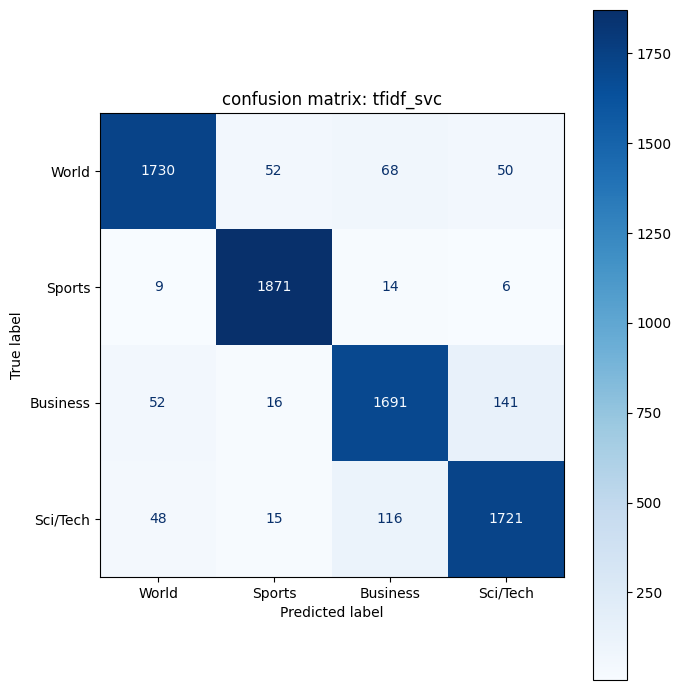

business <-> sci/tech confusion count: 257


,true_name,pred_name,text
20,Sci/Tech,Business,IBM to hire even more new workers By the end o...
23,Sci/Tech,Business,Some People Not Eligible to Get in on Google I...
24,Sci/Tech,Business,Rivals Try to Turn Tables on Charles Schwab By...
83,Business,Sci/Tech,Intel to delay product aimed for high-definiti...
110,Business,Sci/Tech,Yahoo! Ups Ante for Small Businesses Web giant...
111,Sci/Tech,Business,IBM Buys Two Danish Services Firms IBM said Tu...
207,Sci/Tech,Business,Intuit Posts Wider Loss After Charge (Reuters)...
234,Business,Sci/Tech,Justices to debate mail-order wine Being freel...
258,Sci/Tech,Business,"Ciena Posts a Loss, Forecasts Flat Sales &lt;p..."
272,Business,Sci/Tech,"Ohio Sues Best Buy, Alleging Used Sales (AP) A..."


In [ ]:
# reference pattern:
# github notebook for traditional text classification pipelines:
# https://github.com/nlptown/nlp-notebooks/blob/master/Traditional%20text%20classification%20with%20Scikit-learn.ipynb
#
# github notebook for keeping train / validation / test usage disciplined:
# https://github.com/anthony-wang/BestPractices/blob/master/notebooks/2-data_splitting.ipynb

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# reads the unique label values from the official test split
unique_labels = sorted(pd.Series(y_test).dropna().unique().tolist())
print("labels detected in y_test:", unique_labels)

# maps the numeric labels to class names using the detected label scheme
if unique_labels == [1, 2, 3, 4]:
    label_order = [1, 2, 3, 4]
    id2label = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}
elif unique_labels == [0, 1, 2, 3]:
    label_order = [0, 1, 2, 3]
    id2label = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
else:
    raise ValueError(f"unexpected labels found in y_test: {unique_labels}")

# builds one dataframe to inspect the held-out mistakes
error_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true": pd.Series(y_test).reset_index(drop=True),
    "pred": pd.Series(best_classical_pred).reset_index(drop=True)
})

# adds readable class names and a correctness flag
error_df["true_name"] = error_df["true"].map(id2label)
error_df["pred_name"] = error_df["pred"].map(id2label)
error_df["is_correct"] = error_df["true"] == error_df["pred"]

# creates the final held-out confusion matrix
cm = confusion_matrix(error_df["true"], error_df["pred"], labels=label_order)

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[id2label[i] for i in label_order]
)
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=True)
ax.set_title(f"confusion matrix: {best_classical_name}")
plt.tight_layout()
plt.show()

# filters the business versus sci/tech boundary mistakes
pair_errors = error_df[
    ((error_df["true_name"] == "Business") & (error_df["pred_name"] == "Sci/Tech")) |
    ((error_df["true_name"] == "Sci/Tech") & (error_df["pred_name"] == "Business"))
].copy()

# prints and displays a sample of the boundary errors
print("business <-> sci/tech confusion count:", len(pair_errors))
display(pair_errors[["true_name", "pred_name", "text"]].head(20))

# saves the filtered mistakes for report discussion
pair_errors.to_csv("business_scitech_errors.csv", index=False)

In [ ]:
# reference pattern:
# github notebook for traditional text classification pipelines:
# https://github.com/nlptown/nlp-notebooks/blob/master/Traditional%20text%20classification%20with%20Scikit-learn.ipynb

# pulls out the fitted vectorizer and classifier from the best pipeline
vectorizer = best_classical_model.named_steps["vectorizer"]
clf = best_classical_model.named_steps["clf"]

# gets the feature names from the fitted vectorizer
feature_names = vectorizer.get_feature_names_out()

# prints the strongest positive terms for each class if the classifier exposes coefficients
if hasattr(clf, "coef_"):
    for row_idx, class_id in enumerate(clf.classes_):
        class_name = id2label[class_id]
        top_idx = np.argsort(clf.coef_[row_idx])[-15:][::-1]
        top_terms = [feature_names[i] for i in top_idx]

        print(f"\n{class_name} top terms:")
        print(top_terms)
else:
    print("this model does not expose linear coefficients")


World top terms:
['canadian press', 'york stocks', 'athens greece', 'afp afp', 'ap tokyo', 'iraq', 'arafat', 'palestinian', 'iraqi', 'hostage', 'ap president', 'darfur', 'york investors', 'afghanistan', 'press canadian']

Sports top terms:
['coach', 'sports', 'cup', 'nascar', 'stadium', 'nba', 'league', 'team', 'teams', 'baseball', 'nhl', 'turin', 'bryant', 'basketball', 'doping']

Business top terms:
['hellip', 'investing', 'halliburton', 'economy', 'airplanes', 'oracle 39', 'retailers', 'enron', 'adv', 'martha', 'reuters oil', 'york reuters', 'bank', 'insurance', 'airlines']

Sci/Tech top terms:
['nasa', 'washington ap', 'internet', 'linux', 'ap', 'space', 'hp', 'reuters reuters', 'software', 'science', 'wired magazine', 'scientists', 'evolution', 'cybersecurity', 'apple']


## Summary of findings

This notebook compared traditional NLP models and transformer-based models for four-class news classification on the AG News dataset.

The Bag of Words experiments provided a strong baseline and showed that simple sparse representations can already perform well on this task. The TF-IDF experiments improved on this baseline, with TF-IDF plus Linear SVC emerging as the strongest traditional approach and producing strong official test performance. The Word2Vec baseline was weaker, suggesting that averaged static embeddings were less effective here than sparse lexical features.

The transformer section produced the strongest overall results. Fine-tuned DistilBERT achieved the best performance in the notebook, while the ablation experiments showed that training choices such as learning rate, maximum sequence length, and freezing the encoder affected results. The zero-shot FLAN-T5 section was useful as a supplementary comparison, but it was less stable and clearly weaker than the supervised approaches.

Overall, the notebook showed that pretrained transformers delivered the highest classification performance, while carefully tuned traditional models remained competitive, cheaper to train, and easier to interpret.

In [ ]:
# ======================================================
# END OF NOTEBOOK
# ======================================================